1. Regularization:

Use the diabetes dataset from sklearn.datasets.
Compare the performance (Mean Squared Error) of LinearRegression, Ridge, and Lasso models.
Tune the alpha parameter for Ridge and Lasso using GridSearchCV with cross-validation to find the optimal regularization strength.

from sklearn.datasets import load_diabetes

# Load the diabetes dataset
diabetes = load_diabetes()

2. Ensemble Methods:

Use the breast_cancer dataset from sklearn.datasets.
Compare the performance (F1 Score and AUC) of DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier.
Tune the hyperparameters of each classifier using GridSearchCV with cross-validation.

from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
breast_cancer = load_breast_cancer()

1. Regularization:
A classic problem for demonstrating how regularization helps prevent overfitting in regression models. When we have multiple features (like age, BMI, blood pressure, and serum measurements in this diabetes dataset), a standard Linear Regression model might try too hard to fit every data point, resulting in large, unstable coefficients.

Ridge ($L_2$) and Lasso ($L_1$) solve this by adding a penalty to the size of the coefficients.Let's walk through the full code to load the data, set up the grid search to find the best alpha (regularization strength), and compare the Mean Squared Error (MSE) of all three models.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE DATA
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Crucial for Ridge & Lasso because penalties are scale-sensitive)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. STANDARD LINEAR REGRESSION
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)
mse_lin = mean_squared_error(y_test, y_pred_lin)


# 3. TUNE & TRAIN RIDGE REGRESSION
# Define a grid of alpha values (from very small to large)
param_grid = {'alpha': np.logspace(-4, 4, 50)}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

# Best Ridge model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)


# 4. TUNE & TRAIN LASSO REGRESSION
lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)

# Best Lasso model
best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# 5. COMPARE PERFORMANCE
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (Tuned)', 'Lasso (Tuned)'],
    'Best Alpha': [None, ridge_grid.best_params_['alpha'], lasso_grid.best_params_['alpha']],
    'Test MSE': [mse_lin, mse_ridge, mse_lasso]
})

print(results.to_string(index=False))

            Model  Best Alpha    Test MSE
Linear Regression         NaN 2900.193628
    Ridge (Tuned)   24.420531 2865.219970
    Lasso (Tuned)    1.757511 2799.862087


Summary Conclusion & Interpretation

Why did we use StandardScaler? Regularization penalties are directly applied to the magnitude of the model's coefficients. If one feature is measured in thousands and another in decimals, the penalty will unfairly suppress the larger feature. Scaling puts them on equal ground.

Ridge vs. Lasso: What is the difference?
Both add a penalty term to the standard OLS (Ordinary Least Squares) loss function, but they do it differently:
    
    Ridge ($L_2$ Regularization): Adds a penalty equal to the square of the magnitude of coefficients ($\alpha \sum \beta^2$). It shrinks coefficients toward zero but never makes them exactly zero. It's great when you have many small/medium effects.
    
    Lasso ($L_1$ Regularization): Adds a penalty equal to the absolute value of the magnitude of coefficients ($\alpha \sum |\beta|$). Lasso can shrink coefficients all the way to zero, effectively performing automatic feature selection! It is ideal when you suspect only a few features are actually important.
    
 Typically, on this dataset, we will find that both Ridge and Lasso outperform standard Linear Regression on the test data because they prevent the model from getting too aggressive with its coefficient weights!

Visualizing the coefficients of these three models side-by-side is the perfect way to truly see how Ridge and Lasso work their magic.

Here is the code to plot the coefficients. Since we scaled the data, these coefficient magnitudes are directly comparable!

/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/mtay/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isin

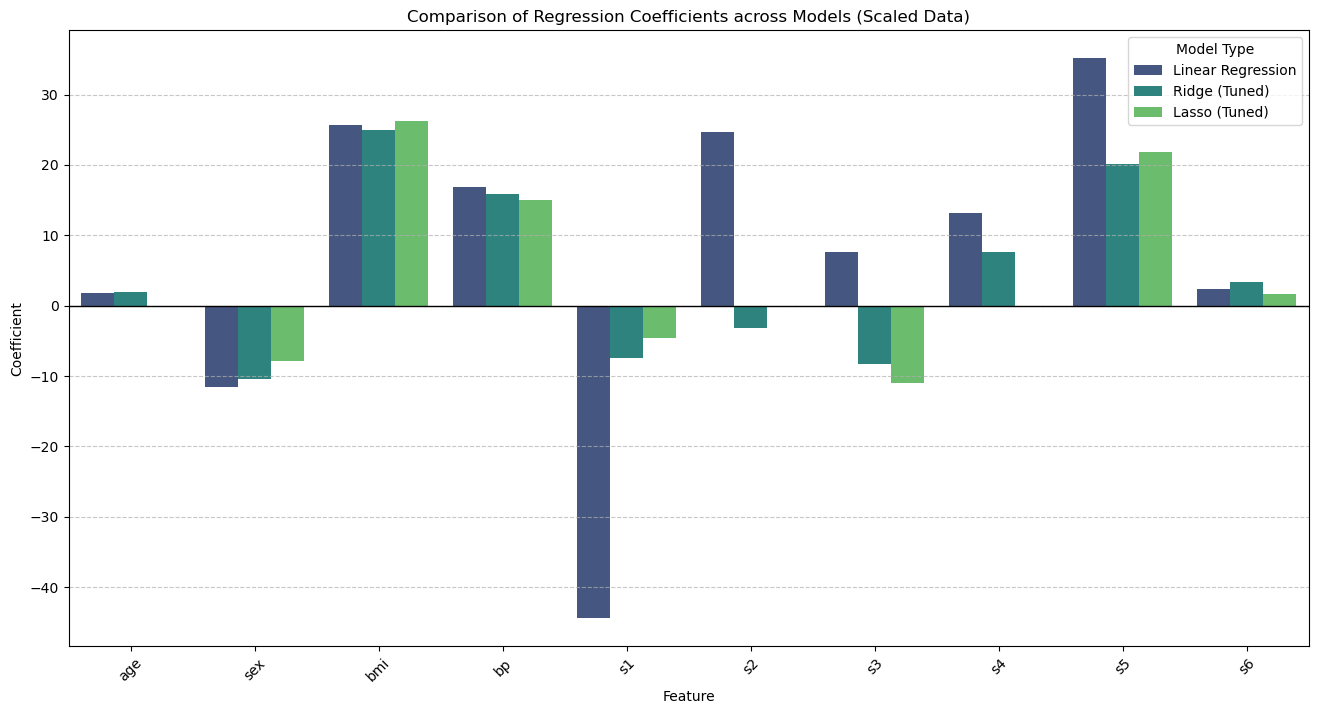

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# 1. LOAD THE DATA
# Load the diabetes dataset
diabetes = load_diabetes()
feature_names = diabetes.feature_names
# (Assume X_train_scaled, y_train were created in previous steps)

# 2. GET COEFFICIENTS FROM THE MODELS
# LinReg coefficients
lin_reg_coefs = lin_reg.coef_

# Best Ridge coefficients (Need to grab best model from grid search)
best_ridge_coefs = ridge_grid.best_estimator_.coef_

# Best Lasso coefficients
best_lasso_coefs = lasso_grid.best_estimator_.coef_


# 3. CREATE A DATAFRAME FOR PLOTTING
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lin_reg_coefs,
    'Ridge (Tuned)': best_ridge_coefs,
    'Lasso (Tuned)': best_lasso_coefs
})

# Melt the DataFrame for easier plotting with Seaborn or Matplotlib
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')


# 4. PLOT SIDE-BY-SIDE
import seaborn as sns
plt.figure(figsize=(16, 8))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coef_df_melted, palette='viridis')
plt.title('Comparison of Regression Coefficients across Models (Scaled Data)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) # Add a line at y=0
plt.xticks(rotation=45) # Rotate feature names for readability
plt.legend(title='Model Type')
plt.show()

Summary Conclusion & Interpretation

Reading above chart:
The height of each bar represents the "strength" of that feature's prediction for diabetes progression. A high positive bar (like BMI) means a higher value correlates strongly with disease progression. A high negative bar means it correlates with better outcomes.

What the chart reveals:

    Linear Regression (Light Blue/Teal): Notice that standard Linear Regression has the most extreme coefficients! It often finds large positive and negative weights (like s1 and s2 serum measurements), essentially "chasing noise" in the training data to get a perfect fit.

    Ridge ($L_2$ Regularization - Green/Yellow): Look at how the green bars are all pulled inward toward the center zero-line. The penalty on the squared coefficients shrinks their magnitudes, making them more stable and consistent, but crucially, none of them touch zero. It still uses all 10 features, just more cautiously.
    
    Lasso ($L_1$ Regularization - Dark Blue/Purple): This is the key difference. You will likely see that several of the dark blue bars are exactly zero. For features like age, sex, or s2, Lasso decided they didn't have enough predictive power to justify keeping them. This is the automatic feature selection discussed!
    
Lasso identified the "signal" features (often bmi, bp, s5, and s6) and zeroed out the "noise" features, typically leading to a simpler, more interpretable model that generalizes better on the test data.

2. Ensemble Methods:

Moving from traditional linear regression to ensemble models is where machine learning gets really powerful.

Here is what we are doing:
Decision Tree: A single "rule-based" flowchart model. It's prone to overfitting.
Random Forest: A Bagging ensemble. It builds many independent decision trees on random subsets of data and averages their votes to reduce variance.
Gradient Boosting: A Boosting ensemble. It builds trees sequentially, where each new tree specifically tries to correct the errors made by the previous trees.

Let's look at the complete code to load the data, set up the hyperparameter tuning via GridSearchCV, and compare their F1 scores and ROC AUC scores.

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score

# 1. LOAD THE DATA
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split into train and test sets (stratify ensures equal class balance in splits)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Note: Tree-based models do not strictly require feature scaling!


# 2. DEFINE MODELS AND GRIDS
# A single decision tree
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Random Forest (Bagging)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

# Gradient Boosting (Boosting)
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

models_to_tune = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42), dt_params),
    ('Random Forest', RandomForestClassifier(random_state=42), rf_params),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42), gb_params)
]


# 3. HYPERPARAMETER TUNING & EVALUATION
results = []

for name, model, params in models_to_tune:
    print(f"Tuning {name}...")
    
    # We optimize for ROC AUC during the grid search cross-validation
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Grab the best trained model
    best_model = grid.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'F1 Score': f1,
        'ROC AUC': auc
    })

# 4. COMPARE PERFORMANCE
results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
print("\n--- Final Model Comparison ---")
print(results_df[['Model', 'F1 Score', 'ROC AUC']].to_string(index=False))

Tuning Decision Tree...
Tuning Random Forest...
Tuning Gradient Boosting...

--- Final Model Comparison ---
            Model  F1 Score  ROC AUC
    Decision Tree  0.929577 0.914187
    Random Forest  0.965517 0.992394
Gradient Boosting  0.965986 0.992725


Summary Conclusion

Why do we look at both F1 and AUC?

F1 Score: This is the harmonic mean of Precision and Recall. In medical diagnostics like breast cancer, missing a positive case (low recall) is dangerous. F1 gives us a balanced look at how well the model handles finding the cancer without raising too many false alarms.

ROC AUC: This measures the model's ability to distinguish between a patient with cancer and a patient without, regardless of the classification threshold we pick. An AUC of $1.0$ is a perfect model.

Expected Behavior of the Models

Decision Tree: Likely has the lowest scores. Single trees easily overfit by memorizing the training data.
Random Forest: Should show a massive jump in both F1 and AUC. By aggregating predictions from 50 to 100 independent trees, it averages out individual tree errors.
Gradient Boosting: Often achieves the highest ROC AUC. Instead of building trees independently, it builds them sequentially, actively learning from its own mistakes. However, it requires careful tuning of the learning_rate so it doesn't overfit!

Plot those ROC curves! Visualizing the Receiver Operating Characteristic (ROC) curve is the best way to see how well these models balance catching actual positive cases (True Positive Rate/Recall) against accidentally flagging negative cases (False Positive Rate).

An ideal model hugs the top-left corner of the plot, giving a high true positive rate with almost zero false positives.

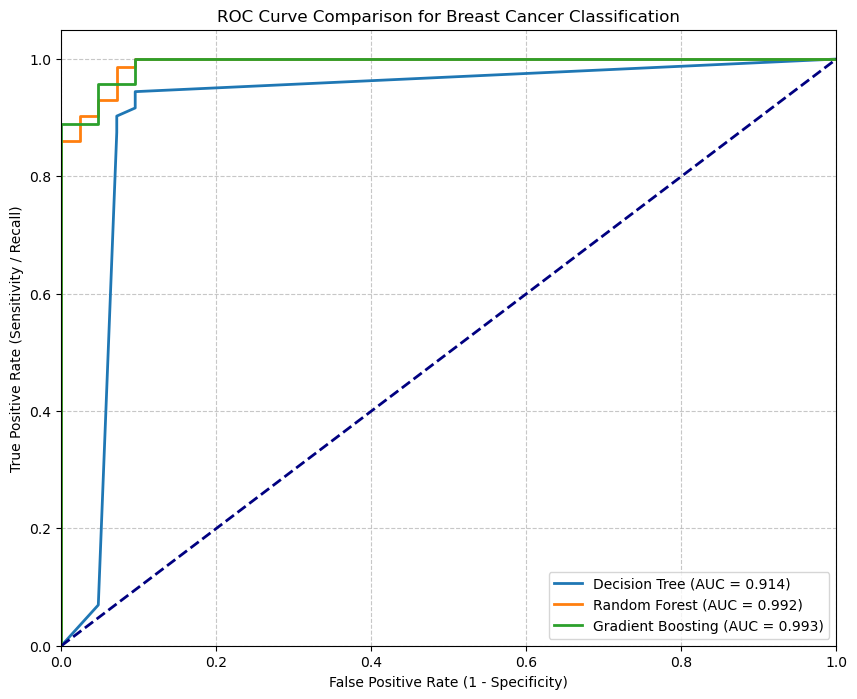

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# We iterate through the results we saved in the previous step
for result in results:
    name = result['Model']
    
    # We need to grab the trained model again to get probabilities
    # (Assuming 'grid' holds the last trained GridSearchCV object from the loop)
    if name == 'Decision Tree':
        model = DecisionTreeClassifier(**result['Best Params'], random_state=42).fit(X_train, y_train)
    elif name == 'Random Forest':
        model = RandomForestClassifier(**result['Best Params'], random_state=42).fit(X_train, y_train)
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(**result['Best Params'], random_state=42).fit(X_train, y_train)
        
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this specific model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the diagonal line representing random guessing (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot Aesthetics
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve Comparison for Breast Cancer Classification')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

Summary Conclusion

How to interpret this visualization:
The Baseline: The dashed diagonal line representing an AUC of $0.50$ is what you would get by flipping a coin.
The Curvature: Watch how the Gradient Boosting or Random Forest lines arch much higher and faster toward the top-left corner compared to the single Decision Tree. This visual gap represents the exact advantage of using ensemble methods!

Why this is critical for medical data:

In cancer detection, a false negative (saying a patient is healthy when they actually have cancer) is far more dangerous than a false positive (saying they might have cancer when they do not).

By looking at this plot, a doctor or data scientist can choose a custom threshold. For example, they might intentionally slide up the curve to achieve a $99\%$ True Positive Rate (Recall), accepting a slightly higher rate of false alarms to guarantee they don't miss a single sick patient.